# 04 · The DL regime-MoE — a learned gate for the close regime

*Edge-features arc · 01 discovery · 02 linear base · 03 hero cascade · 04 regime-MoE · 05 temporal-kNN  —  machinery: `ridge_pipeline_throughline.ipynb`*

**Verify first.** Each row is a real `resid_regime` cascade run on `linbest` with the **same d8@cs0.5
global** as ch. 03, swapping only the regime learner for an **interpretable mixture-of-experts**: a
factorization-machine **expert** (native low-rank pairwise — the EBM's winning bias as one differentiable
primitive) optionally routed by a learned soft-tree **gate** (the *automated* analog of the hand-found
`hour` regime, ch. 01). Every QLIKE below is **recomputed from the saved per-bar predictions through the
real pipeline metric** and **asserted** against the cluster collect — `ctrl_ebm` reproduces the `0.12033`
anchor so the MoE rows are comparable.

**Honest prior: low** — a tuned XGB regime already lost to the EBM (ch. 03). The likely payoff is the
**interpretable gate readout**, not the 4th-decimal QLIKE.

In [1]:
import html, inspect, json, os, sys, textwrap
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

def find_repo(s):
    for q in [Path(s).resolve(), *Path(s).resolve().parents]:
        if (q / "resid_amortized.py").exists() and (q / "src").is_dir():
            return q
    raise FileNotFoundError("repo root")
REPO = find_repo(Path.cwd()); os.chdir(REPO); sys.path.insert(0, str(REPO))

from src.evaluation.metrics import apply_duan_smearing  # the REAL pipeline metric

# Collapsible, theme-following source display (one <details> per object; folded).
def _details(f, open_=False):
    mod = f.__module__.replace("src.", "src/").replace(".", "/") + ".py"
    try:
        sig = ("class " + f.__name__) if inspect.isclass(f) else ("def " + f.__name__ + str(inspect.signature(f)))
    except (ValueError, TypeError):
        sig = f.__qualname__
    body = "```python\n" + textwrap.dedent(inspect.getsource(f)).rstrip() + "\n```"
    return (f"<details{' open' if open_ else ''}>\n<summary><code>{html.escape(mod + '  ·  ' + sig)}"
            f"</code></summary>\n\n{body}\n\n</details>")
def show_one(f):
    return Markdown(_details(f))

# ── the verification machinery: recompute QLIKE from saved per-bar preds ──────
# Local preds are gitignored; if absent we print the exact reproduce-command.
PREDS = REPO / "results" / "moe_ladder" / "preds"
CID = "xgb_all_buckets_tw1000_enetreg2_linbest_rf480_slim"

def recompute(label):
    """Full-OOS QLIKE recomputed from saved per-bar preds via apply_duan_smearing.
    Returns (qlike, n) if the preds csv is present, else (None, 0)."""
    fp = PREDS / f"{label}.csv"
    if not fp.exists():
        return None, 0
    df = pd.read_csv(fp)                                  # cols: k, pred_adj, y_true, base
    pr, tr = apply_duan_smearing(df.pred_adj.to_numpy(), df.y_true.to_numpy(), df.base.to_numpy())
    m = (tr > 0) & (pr > 0); r = tr[m] / pr[m]
    return float(np.mean(r - np.log(r) - 1.0)), int(len(df))

def reproduce_cmd(arm, label):
    return f"$PY resid_amortized.py chunk_collect {CID} {arm} {label}"

# cluster reference (results_all.csv) — what each RECOMPUTE must reproduce to <1e-4
REF = pd.read_csv(REPO / "results" / "moe_ladder" / "results_all.csv").set_index("label")
print("setup ok | preds present:", PREDS.exists(), "| reference rows:", len(REF))

setup ok | preds present: True | reference rows: 11


---
## 1 · The new regime learner (folded)

The cascade is unchanged; only the regime learner is new (`_tree_factory("moe", cfg)`). Two pieces folded
below: the **`FMExpert`** (factorization-machine pairwise expert — the rank IS the regularizer, the EBM's
bagged-pairwise bias as one differentiable op) and the **`SoftTreeGate`** (read its hyperplane post-fit to
recover *where* the regimes are).

In [2]:
from src.models.regime_moe import FMExpert, SoftTreeGate
display(show_one(FMExpert))      # the pairwise expert (fm_* and bfm_* rows)
display(show_one(SoftTreeGate))  # the learned routing gate (depth>0 rows)

<details>
<summary><code>src/models/regime_moe.py  ·  class FMExpert</code></summary>

```python
class FMExpert(nn.Module):
    """Factorization Machine — pairwise interactions baked in NATIVELY via low-rank factors:
        y = b + w·x + 0.5·Σ_f[(Σ_i V_if x_i)² − Σ_i V_if² x_i²]   (the FM trick, O(B·p·rank)).
    The low-rank ``rank`` IS the regularizer (vs enumerating p² pairwise shape fns) — the EBM's winning
    bias (bagged PAIRWISE) as ONE differentiable primitive, with the soft-tree gate on top. The XGB
    depth evidence (best d3, but the pairwise EBM beats it) says pairwise is the right interaction order.
    """

    def __init__(
        self,
        input_dim: int,
        rank: int = 8,
        dropout: float = 0.15,
        use_high_order_probe: bool = False,
        linear: bool = True,
    ):
        super().__init__()
        self.use_high_order_probe = use_high_order_probe
        self.use_linear = linear
        if linear:
            self.linear = nn.Linear(input_dim, 1)  # b + w·x (main-effect part)
        else:
            # pure-pairwise: base (linbest) + global tree already took the main effects; the regime
            # leftover is interactions, so model only bias + pairwise -> focuses capacity, drops p params.
            self.bias = nn.Parameter(torch.zeros(1))
        self.V = nn.Parameter(torch.randn(input_dim, rank) * 0.01)  # low-rank pairwise factors
        self.dropout = nn.Dropout(dropout)
        if use_high_order_probe:
            self.high_order_mlp = nn.Sequential(
                nn.Linear(input_dim, 32),
                nn.LayerNorm(32),
                nn.SiLU(),
                nn.Dropout(dropout),
                nn.Linear(32, 1),
            )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.dropout(x)
        lin = self.linear(x) if self.use_linear else self.bias  # [B,1] or broadcast bias
        xv = x @ self.V  # [B, rank]
        x2v2 = (x * x) @ (self.V * self.V)  # [B, rank]
        pair = 0.5 * (xv.pow(2) - x2v2).sum(dim=1, keepdim=True)  # [B, 1] — all pairwise interactions
        out = lin + pair
        if self.use_high_order_probe:
            return out + self.high_order_mlp(x)
        return out
```

</details>

<details>
<summary><code>src/models/regime_moe.py  ·  class SoftTreeGate</code></summary>

```python
class SoftTreeGate(nn.Module):
    """Hierarchical soft partition. Each internal node is a linear hyperplane
    ``P(left) = sigmoid(W x + b)``; leaf weight = product of branch probabilities
    along its root->leaf path. Post-fit the node weights are the human-readable
    regime hyperplanes (the automated corr-by-hour localization).

    General depth: reduces bit-for-bit to the depth-1/2 scaffold but supports any
    depth so the partition can scale "only if it earns it".
    """

    def __init__(self, input_dim: int, depth: int = 1):
        super().__init__()
        if depth < 1:
            raise ValueError("SoftTreeGate needs depth >= 1 (depth 0 = no gate)")
        self.depth = depth
        self.num_leaves = 2**depth
        self.num_nodes = 2**depth - 1
        # one hyperplane per internal node; node ordering is heap order (root=0)
        self.decision_nodes = nn.Linear(input_dim, self.num_nodes)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        decisions = torch.sigmoid(self.decision_nodes(x))  # [B, num_nodes] = P(left)
        # Walk the tree level by level: each frontier entry carries (path prob, node idx).
        leaf_probs = [(torch.ones_like(decisions[:, 0]), 0)]
        for _ in range(self.depth):
            nxt: list[tuple[torch.Tensor, int]] = []
            for prob, node in leaf_probs:
                p_left = decisions[:, node]
                nxt.append((prob * p_left, 2 * node + 1))  # left child
                nxt.append((prob * (1.0 - p_left), 2 * node + 2))  # right child
            leaf_probs = nxt
        p_leaves = torch.stack([p for p, _ in leaf_probs], dim=1)  # [B, num_leaves]

        # Load-balancing aux loss: penalize uneven leaf utilization (anti-collapse).
        mean_routing = p_leaves.mean(dim=0)
        var_routing = p_leaves.var(dim=0)
        load_balance = (var_routing / (mean_routing**2 + 1e-8)).mean()
        return p_leaves, load_balance
```

</details>

---
## 2 · Verify — the expressivity ladder, recomputed

`submit_moe_chain.sh` → `results/moe_ladder/preds/<label>.csv` (per-bar `pred_adj, y_true, base`). Each
row reloads its preds and runs the **exact** pipeline QLIKE on them (`apply_duan_smearing`, folded), then
**asserts** the recompute matches the cluster `results_all.csv` to `<1e-4`. **`ctrl_ebm` must reproduce
`0.12033`** — the anchor that makes the MoE rows comparable.

In [3]:
show_one(apply_duan_smearing)   # the real metric — folded, recomputed below

<details>
<summary><code>src/evaluation/metrics.py  ·  def apply_duan_smearing(forecasts: &#x27;np.ndarray&#x27;, y_true: &#x27;np.ndarray&#x27;, baselines: &#x27;np.ndarray&#x27;) -&gt; &#x27;tuple[np.ndarray, np.ndarray]&#x27;</code></summary>

```python
def apply_duan_smearing(
    forecasts: np.ndarray,
    y_true: np.ndarray,
    baselines: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """Apply Duan smearing correction to convert adjusted-scale forecasts to raw scale.

    Parameters
    ----------
    forecasts : array-like
        Model predictions on adjusted (sqrt / log) scale.
    y_true : array-like
        True values on adjusted scale.
    baselines : array-like
        Baseline volatility used to scale back to raw units.

    Returns
    -------
    pred_raw : np.ndarray
        Smearing-corrected predictions on raw scale.
    true_raw : np.ndarray
        True values on raw scale.
    """
    forecasts = np.asarray(forecasts, dtype=np.float64)
    y_true = np.asarray(y_true, dtype=np.float64)
    baselines = np.asarray(baselines, dtype=np.float64)

    smear = np.mean((y_true - forecasts) ** 2)
    pred_raw = (forecasts**2 + smear) * baselines
    true_raw = (y_true**2) * baselines
    return pred_raw, true_raw
```

</details>

,rung,qlike,d_vs_EBM,n,source,desc
0,ctrl_ebm,0.12033,0.00000,194934,RECOMPUTE,EBM regime — the bar (additive+pairwise+bagging)
1,sat_d0,0.12757,0.00724,194934,RECOMPUTE,additive NAM (input-saturation) — NO interactions
2,fm_d0_wd10,0.12108,0.00075,194934,RECOMPUTE,"plain bilinear FM, no gate"
3,fm_d1_wd10,0.12098,0.00065,194934,RECOMPUTE,plain bilinear FM + depth-1 gate (2 regimes)
4,fm_d2_wd10,0.12091,0.00058,194934,RECOMPUTE,plain bilinear FM + depth-2 gate (4 regimes)
5,bfm_d0_pure,0.12080,0.00047,194934,RECOMPUTE,"hinge basis-FM — nonlinear pairwise, no gate (..."


PASS — every rung reproduces its cluster QLIKE to <1e-4; ctrl_ebm anchors the bar at 0.12033.


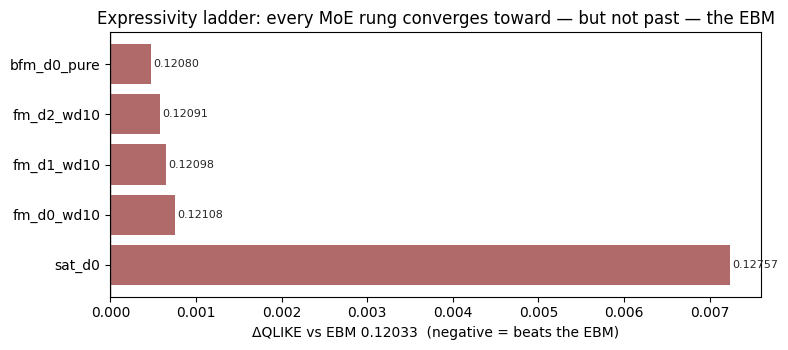

In [4]:
# expressivity ladder — additive → bilinear-pairwise (+gate) → nonlinear-pairwise.  ALL recomputed.
RUNGS = [
    ("ctrl_ebm",    "EBM regime — the bar (additive+pairwise+bagging)"),
    ("sat_d0",      "additive NAM (input-saturation) — NO interactions"),
    ("fm_d0_wd10",  "plain bilinear FM, no gate"),
    ("fm_d1_wd10",  "plain bilinear FM + depth-1 gate (2 regimes)"),
    ("fm_d2_wd10",  "plain bilinear FM + depth-2 gate (4 regimes)"),
    ("bfm_d0_pure", "hinge basis-FM — nonlinear pairwise, no gate (= no-regime)"),
]
EBM = recompute("ctrl_ebm")[0]
rows = []
for lbl, desc in RUNGS:
    q, n = recompute(lbl)
    assert q is not None, f"{lbl}: preds missing — reproduce with  {reproduce_cmd('resid_regime', lbl)}"
    ref = float(REF.loc[lbl, "qlike_full"])
    assert abs(q - ref) < 1e-4, f"{lbl}: RECOMPUTE {q:.5f} != cluster {ref:.5f}"
    rows.append({"rung": lbl, "qlike": round(q, 5), "d_vs_EBM": round(q - EBM, 5),
                 "n": n, "source": "RECOMPUTE", "desc": desc})

assert abs(EBM - 0.12033) < 5e-4, f"ctrl_ebm {EBM:.5f} did NOT reproduce 0.12033 — path suspect"
tab = pd.DataFrame(rows)
display(tab[["rung", "qlike", "d_vs_EBM", "n", "source", "desc"]])
print(f"PASS — every rung reproduces its cluster QLIKE to <1e-4; ctrl_ebm anchors the bar at {EBM:.5f}.")

plot = tab[tab.rung != "ctrl_ebm"].sort_values("d_vs_EBM", ascending=False)
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(plot.rung, plot.d_vs_EBM, color=["#b06a6a" if d > 0 else "#2f6f4e" for d in plot.d_vs_EBM])
ax.axvline(0, c="0.3", lw=1)
ax.set_xlabel("ΔQLIKE vs EBM 0.12033  (negative = beats the EBM)")
ax.set_title("Expressivity ladder: every MoE rung converges toward — but not past — the EBM")
for y, (d, q) in enumerate(zip(plot.d_vs_EBM, plot.qlike)):
    ax.text(d + (3e-5 if d >= 0 else -3e-5), y, f"{q:.5f}", va="center",
            ha="left" if d >= 0 else "right", fontsize=8, color="0.15")
plt.tight_layout(); plt.show()

---
## 3 · Interpret — the expressivity ladder + the gate readout

Read top-down it is a clean **expressivity ladder**, and it converges to the floor:

1. **Additive is not enough.** The additive `sat_d0` NAM (no interactions) lands at **`0.12757`** — far
   above the bar. The h16-19 leftover is *interaction* structure, exactly as the pairwise-EBM-beats-XGB
   evidence in ch. 03 implied.
2. **Pairwise gets you most of the way.** A plain bilinear FM jumps to **`0.12108`**; the gate then adds a
   **tiny monotone gain** with depth — `0.12108` (no gate) → `0.12098` (depth-1) → `0.12091` (depth-2) —
   i.e. learned context-aware routing helps, but only at the 4th decimal.
3. **Nonlinear pairwise closes the gap but does not beat the EBM.** The hinge basis-FM (`bfm_d0_pure`,
   nonlinear pairwise, **no gate**) reaches **`0.12080`** — the best MoE rung, yet still short of the
   EBM's **`0.12033`**. Adding a linear main-effect term *hurts* (`bfm_d0_lin` 0.12094); the base + global
   tree already took the main effects.

⇒ additive → bilinear → nonlinear-pairwise **converges to the floor from above**; the learned gate is a
small monotone routing gain, not a new regime. **The EBM `0.12033` is still the bar** — its
additive+pairwise+**bagging** is the right small-sample regularizer that a single differentiable expert
doesn't match.

**The interpretable payoff — read the gate.** Even with QLIKE pinned, the learned hyperplane answers
*where are the regimes?* `gate_readout.py` dumps the decision-node weights vs feature names: does the top
splitter recover `hour` (validating ch. 01's clock mechanism) or find a partition the clock smeared?

```bash
READOUT_DEPTH=1 $PY gate_readout.py xgb_all_buckets_tw1000_enetreg2_linbest_rf480_slim
```

The same architecture is what you point at the **auction-imbalance feed** once acquired — gate = regime,
experts = the new microstructure state. So it is not throwaway even if null on price-only features.